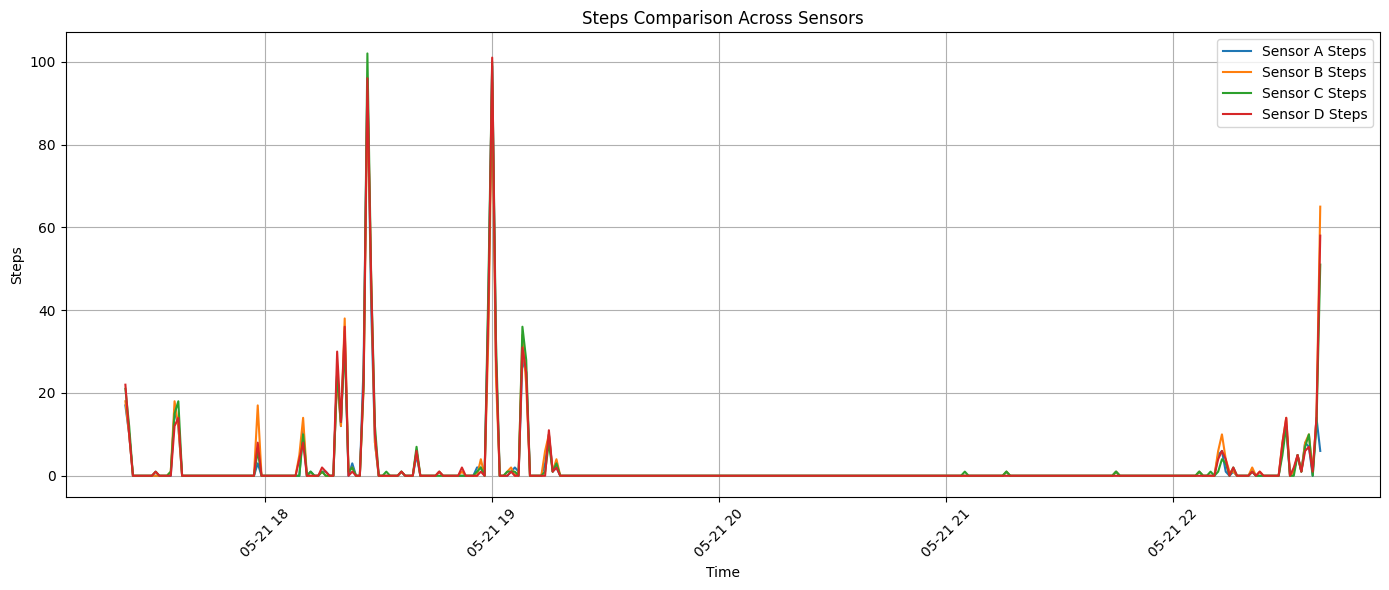

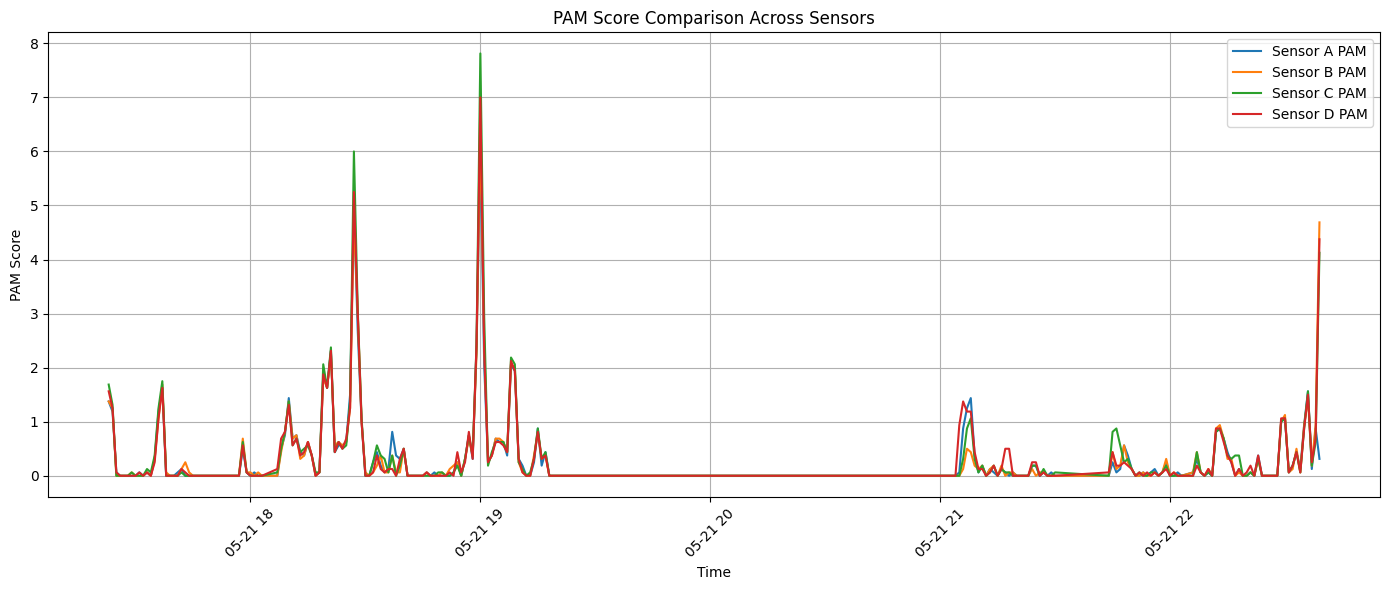

Summary Table (Totals):


,Metric,Sensor A,Sensor B,Sensor C,Sensor D
0,Total Steps,650.0,744.0000,733.0000,724.0000
1,Total PAM Score,73.5,75.4375,82.4375,79.8125



Pairwise Differences:


,Metric,Sensor Pair,Difference
0,Total Steps,Sensor A - Sensor B,-94.0000
1,Total Steps,Sensor A - Sensor C,-83.0000
2,Total Steps,Sensor A - Sensor D,-74.0000
3,Total Steps,Sensor B - Sensor C,11.0000
4,Total Steps,Sensor B - Sensor D,20.0000
5,Total Steps,Sensor C - Sensor D,9.0000
6,Total PAM Score,Sensor A - Sensor B,-1.9375
7,Total PAM Score,Sensor A - Sensor C,-8.9375
8,Total PAM Score,Sensor A - Sensor D,-6.3125
9,Total PAM Score,Sensor B - Sensor C,-7.0000


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from itertools import combinations

# === File setup ===
sensor_files = {
    "Sensor A": "Test_data_90242.csv",
    "Sensor B": "Test_data_90243.csv",
    "Sensor C": "Test_data_90245.csv",
    "Sensor D": "Test_data_90248.csv"
}

# === Load data ===
dfs = {}
for name, file in sensor_files.items():
    df = pd.read_csv(file, parse_dates=["Timestamp"])
    df = df.rename(columns={
        "Steps": f"Steps_{name}",
        "PAM Score": f"PAM_{name}"
    })
    dfs[name] = df

# === Merge all data on Timestamp ===
from functools import reduce
merged = reduce(lambda left, right: pd.merge(left, right, on="Timestamp"), dfs.values())

# === Plot Steps for all sensors ===
plt.figure(figsize=(14, 6))
for name in sensor_files:
    plt.plot(merged["Timestamp"], merged[f"Steps_{name}"], label=f"{name} Steps")
plt.title("Steps Comparison Across Sensors")
plt.xlabel("Time")
plt.ylabel("Steps")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# === Plot PAM Scores for all sensors ===
plt.figure(figsize=(14, 6))
for name in sensor_files:
    plt.plot(merged["Timestamp"], merged[f"PAM_{name}"], label=f"{name} PAM")
plt.title("PAM Score Comparison Across Sensors")
plt.xlabel("Time")
plt.ylabel("PAM Score")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# === Create summary table with totals ===
summary_data = {
    'Metric': ['Total Steps', 'Total PAM Score']
}

for name in sensor_files:
    steps_total = merged[f"Steps_{name}"].sum()
    pam_total = merged[f"PAM_{name}"].sum()
    summary_data[name] = [steps_total, pam_total]

summary_table = pd.DataFrame(summary_data)

# Display summary
summary_table

# === Compute pairwise differences ===
pairwise_diff_rows = []

sensor_names = list(sensor_files.keys())

for metric_idx, metric_name in enumerate(['Total Steps', 'Total PAM Score']):
    for sensor1, sensor2 in combinations(sensor_names, 2):
        value1 = summary_table.loc[metric_idx, sensor1]
        value2 = summary_table.loc[metric_idx, sensor2]
        diff = value1 - value2
        pairwise_diff_rows.append({
            'Metric': metric_name,
            'Sensor Pair': f"{sensor1} - {sensor2}",
            'Difference': diff
        })

pairwise_diff_table = pd.DataFrame(pairwise_diff_rows)

# === Display tables ===
print("Summary Table (Totals):")
display(summary_table)

print("\nPairwise Differences:")
display(pairwise_diff_table)